# Netflix Originals: Advanced Analytical Deep Dive
**Upgraded Exploratory & Statistical Analysis Notebook**

**Project:** Data Analyst Portfolio Upgrade (SQL + Python + Power BI)  
**Author:** Data Strategy & Analytics  
**Dataset:** `NetflixOriginals.csv` (584 titles, 2014 - May 2021)  

### Project Framework: 3 Questions, 3 Tools, 3 Dashboard Pages
- **Question 1: Portfolio Mix** — Catalog composition by genre, language, YoY scaling, and release timing.
- **Question 2: Perceived Quality** — Perceived quality benchmarks (IMDb score), acclaim share (>= 7.0), and runtime relationships.
- **Question 3: Outliers & Strategic Gaps** — Statistical outliers (IQR & z-score) and underperforming content opportunities.

---

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Plotting aesthetic
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'figure.dpi': 120
})

# Paths
DB_PATH = os.path.join("..", "netflix.db")
CSV_PATH = os.path.join("..", "data", "processed", "powerbi", "fact_titles.csv")

df = pd.read_csv(CSV_PATH)
print(f"Loaded fact_titles: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(3)

Loaded fact_titles: 584 rows, 13 columns


,title_id,title,date_key,primary_genre_id,primary_genre_name,genre_group,primary_language_id,primary_language,is_multilingual,runtime,runtime_bucket,imdb_score,score_bucket
0,1,Enter the Anime,20190805,1,Documentary,Documentary,1,English,1,58.0,Standard (40-120m),2.5,Low (<5.5)
1,2,Dark Forces,20200821,2,Thriller,Thriller/Crime/Horror,3,Spanish,0,81.0,Standard (40-120m),2.6,Low (<5.5)
2,3,The App,20191226,3,Science fiction,Sci-Fi/Fantasy/Animation,4,Italian,0,79.0,Standard (40-120m),2.6,Low (<5.5)


## Question 1: Language and Extended Runtimes
**Original Notebook Question:** *"In which language was the long hour film created"*

**Audit Findings & Fix:**
- The original notebook ran `.groupby(['Language','Title'])['Runtime'].mean()`, which is redundant because `Title` is already unique.
- Here, we evaluate long-hour films (> 120 min) across languages and compare average feature lengths by language (for reliable groups $n \ge 10$).

Top 8 Longest Films:
                          title primary_language           genre_group  runtime  imdb_score
                   The Irishman          English Thriller/Crime/Horror    209.0         7.8
                    Da 5 Bloods          English                 Drama    155.0         6.5
        Springsteen on Broadway          English Music/Concert/Special    153.0         8.5
             The Forest of Love         Japanese                 Drama    151.0         6.3
                       Citation          English                 Drama    151.0         6.2
                 Raat Akeli Hai            Hindi Thriller/Crime/Horror    149.0         7.3
                           Ludo            Hindi                Comedy    149.0         7.6
The Last Days of American Crime          English Thriller/Crime/Horror    149.0         3.7


C:\Users\naman\AppData\Local\Temp\ipykernel_23600\92801348.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_major_lang, x='primary_language', y='runtime', order=major_langs, palette='crest')


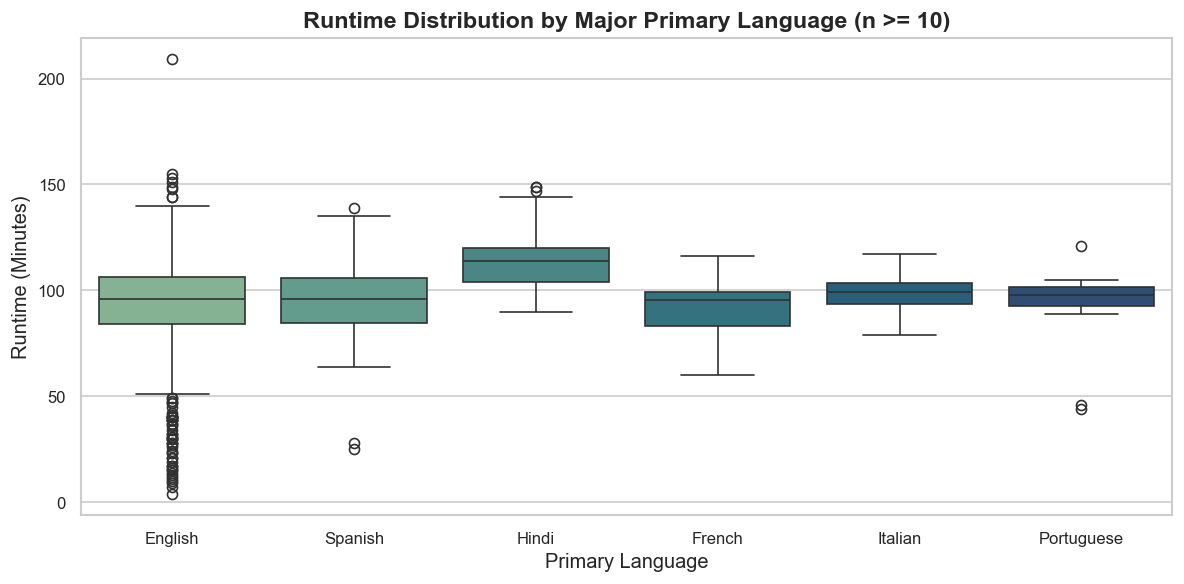


Major Language Runtime Benchmarks:
                  count   mean  median
primary_language                      
English             419   90.8    96.0
French               20   92.7    95.5
Hindi                33  115.8   114.0
Italian              14   98.4    99.0
Portuguese           12   91.2    98.0
Spanish              34   94.0    96.0


In [2]:
# 1. Top longest individual films
longest_films = df.sort_values(by='runtime', ascending=False)[['title', 'primary_language', 'genre_group', 'runtime', 'imdb_score']].head(8)
print("Top 8 Longest Films:")
print(longest_films.to_string(index=False))

# 2. Runtime distribution across languages with n >= 10
lang_counts = df['primary_language'].value_counts()
major_langs = lang_counts[lang_counts >= 10].index.tolist()
df_major_lang = df[df['primary_language'].isin(major_langs)]

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_major_lang, x='primary_language', y='runtime', order=major_langs, palette='crest')
plt.title('Runtime Distribution by Major Primary Language (n >= 10)', weight='bold')
plt.xlabel('Primary Language')
plt.ylabel('Runtime (Minutes)')
plt.tight_layout()
plt.show()

lang_rt_summary = df_major_lang.groupby('primary_language')['runtime'].agg(['count', 'mean', 'median']).round(1)
print("\nMajor Language Runtime Benchmarks:")
print(lang_rt_summary)

## Question 2: Documentary Quality Trajectory (Jan 2019 – June 2020)
**Original Notebook Question:** *"Find and visualize the IMDB values of the movies shot in the 'Documentary' genre between January 2019 and June 2020."*

**Audit Findings & Fix:**
- The original notebook produced two cluttered Plotly scatter plots with 60 titles colored individually, creating an unreadable legend.
- We filter accurately by date range and display a clean scatter plot with median benchmark bands and annotated marquee titles.

Documentaries released between Jan 2019 and Jun 2020: 56 titles
Mean IMDb Score: 6.80 | Median: 7.00


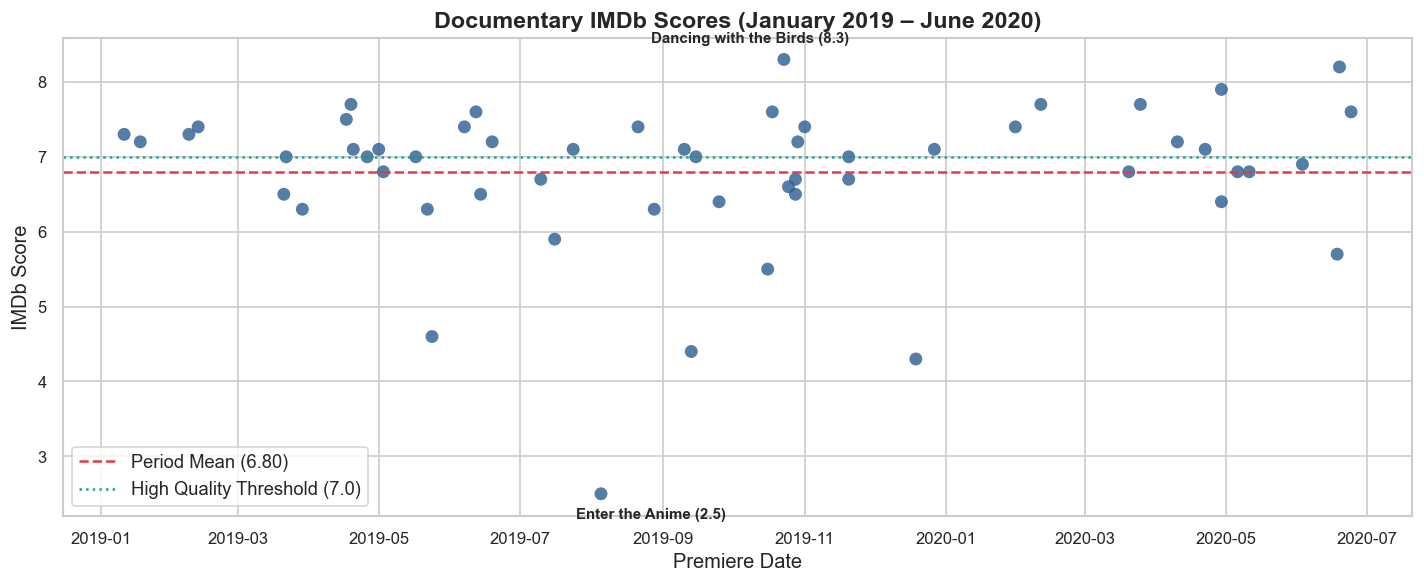

In [3]:
conn = sqlite3.connect(DB_PATH)
q2_query = """
SELECT 
    f.title,
    d.full_date,
    d.year,
    d.month_name,
    f.imdb_score,
    f.runtime
FROM fact_titles f
JOIN dim_date d ON f.date_key = d.date_key
WHERE f.genre_group = 'Documentary'
  AND d.full_date >= '2019-01-01' 
  AND d.full_date <= '2020-06-30'
ORDER BY d.full_date;
"""
df_doc_window = pd.read_sql(q2_query, conn)
conn.close()

print(f"Documentaries released between Jan 2019 and Jun 2020: {len(df_doc_window)} titles")
print(f"Mean IMDb Score: {df_doc_window['imdb_score'].mean():.2f} | Median: {df_doc_window['imdb_score'].median():.2f}")

plt.figure(figsize=(12, 5))
df_doc_window['date_dt'] = pd.to_datetime(df_doc_window['full_date'])
plt.scatter(df_doc_window['date_dt'], df_doc_window['imdb_score'], color='#2b5c8f', s=60, alpha=0.8, edgecolors='none')
plt.axhline(df_doc_window['imdb_score'].mean(), color='#e63946', linestyle='--', linewidth=1.5, label=f"Period Mean ({df_doc_window['imdb_score'].mean():.2f})")
plt.axhline(7.0, color='#2a9d8f', linestyle=':', linewidth=1.5, label="High Quality Threshold (7.0)")

# Annotate top and bottom titles
top_doc = df_doc_window.loc[df_doc_window['imdb_score'].idxmax()]
bot_doc = df_doc_window.loc[df_doc_window['imdb_score'].idxmin()]
plt.annotate(f"{top_doc['title']} ({top_doc['imdb_score']})", (top_doc['date_dt'], top_doc['imdb_score']),
             textcoords="offset points", xytext=(-20, 10), ha='center', weight='bold', fontsize=9)
plt.annotate(f"{bot_doc['title']} ({bot_doc['imdb_score']})", (bot_doc['date_dt'], bot_doc['imdb_score']),
             textcoords="offset points", xytext=(30, -15), ha='center', weight='bold', fontsize=9)

plt.title('Documentary IMDb Scores (January 2019 – June 2020)', weight='bold')
plt.xlabel('Premiere Date')
plt.ylabel('IMDb Score')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

## Question 3: English-Language Perceived Quality by Genre
**Original Notebook Question:** *"Which genre has the highest IMDB rating among movies shot in English?"*

**Audit Findings & Fix:**
- The original notebook grouped by `['Language','Genre','Title']` and printed individual movie titles rather than genre averages.
- Here, we group English titles by standardized `genre_group`, requiring $n \ge 10$ to ensure statistical reliability.

English Titles Perceived Quality by Genre Group:
             genre_group  title_count  avg_score  median_score  pct_high_rated
             Documentary          137   6.954015           7.1       58.394161
   Music/Concert/Special           28   6.632143           6.9       50.000000
                   Drama           53   6.577358           6.5       26.415094
  Action/Adventure/Other           14   6.257143           6.3       21.428571
Sci-Fi/Fantasy/Animation           37   6.148649           6.3       21.621622
                 Romance           37   6.018919           6.0        2.702703
                  Comedy           60   5.800000           5.7        5.000000
   Thriller/Crime/Horror           53   5.758491           5.9        5.660377


C:\Users\naman\AppData\Local\Temp\ipykernel_23600\1827214156.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eng_genre_perf, x='avg_score', y='genre_group', palette='Blues_r')


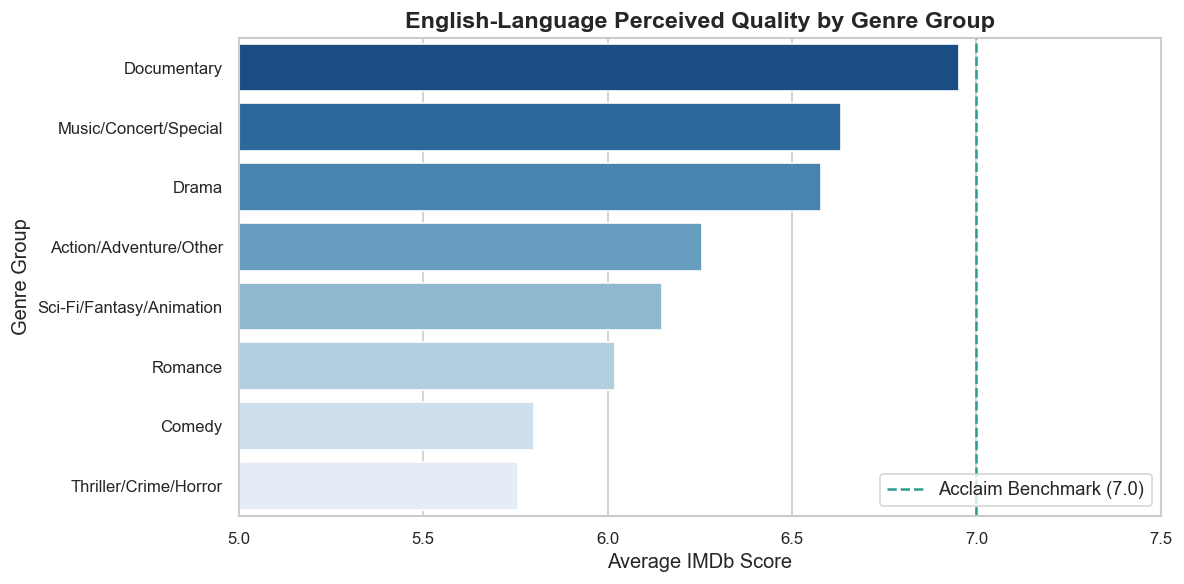

In [4]:
df_eng = df[df['primary_language'] == 'English']
eng_genre_perf = df_eng.groupby('genre_group').agg(
    title_count=('title_id', 'count'),
    avg_score=('imdb_score', 'mean'),
    median_score=('imdb_score', 'median'),
    pct_high_rated=('imdb_score', lambda s: (s >= 7.0).mean() * 100)
).reset_index().sort_values(by='avg_score', ascending=False)

print("English Titles Perceived Quality by Genre Group:")
print(eng_genre_perf.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=eng_genre_perf, x='avg_score', y='genre_group', palette='Blues_r')
plt.axvline(7.0, color='#2a9d8f', linestyle='--', label='Acclaim Benchmark (7.0)')
plt.title('English-Language Perceived Quality by Genre Group', weight='bold')
plt.xlabel('Average IMDb Score')
plt.ylabel('Genre Group')
plt.xlim(5.0, 7.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Question 4: Average Runtime of Hindi-Language Titles
**Original Notebook Question:** *"What is the average 'runtime' of movies shot in 'Hindi'?"*

**Audit Findings & Fix:**
- The original notebook printed `data_hindi.Runtime.mean()` as an isolated number (115.73 min).
- Here, we benchmark Hindi runtime against platform averages and all major language groups.

Hindi Titles Count: 33
Hindi Mean Runtime: 115.79 minutes
Hindi Median Runtime: 114.0 minutes
Catalog Overall Mean Runtime: 93.58 minutes
Difference vs Overall: +22.21 minutes (+23.7%)


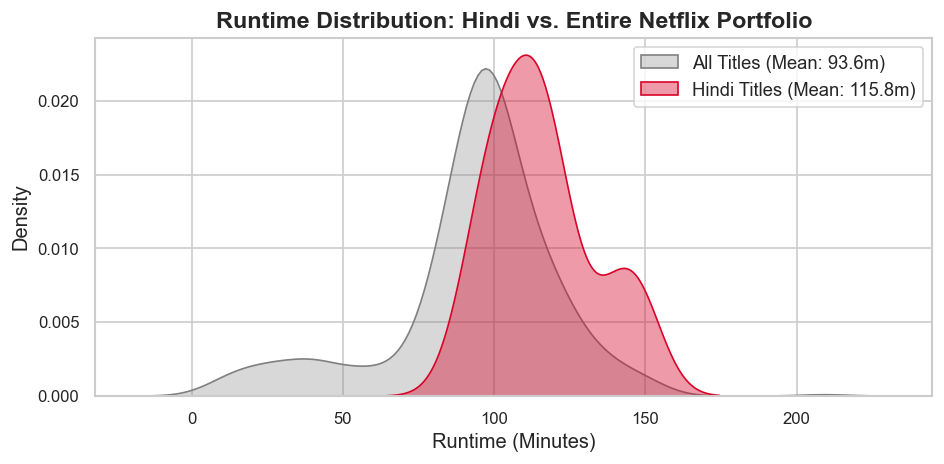

In [5]:
hindi_df = df[df['primary_language'] == 'Hindi']
hindi_mean = hindi_df['runtime'].mean()
hindi_median = hindi_df['runtime'].median()
overall_mean = df['runtime'].mean()

print(f"Hindi Titles Count: {len(hindi_df)}")
print(f"Hindi Mean Runtime: {hindi_mean:.2f} minutes")
print(f"Hindi Median Runtime: {hindi_median:.1f} minutes")
print(f"Catalog Overall Mean Runtime: {overall_mean:.2f} minutes")
print(f"Difference vs Overall: +{hindi_mean - overall_mean:.2f} minutes (+{((hindi_mean/overall_mean)-1)*100:.1f}%)")

plt.figure(figsize=(8, 4))
sns.kdeplot(df['runtime'], label=f'All Titles (Mean: {overall_mean:.1f}m)', color='gray', fill=True, alpha=0.3)
sns.kdeplot(hindi_df['runtime'], label=f'Hindi Titles (Mean: {hindi_mean:.1f}m)', color='#d90429', fill=True, alpha=0.4)
plt.title('Runtime Distribution: Hindi vs. Entire Netflix Portfolio', weight='bold')
plt.xlabel('Runtime (Minutes)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

## Question 5: Genre Breakdown and Audit Proof of the Positional Bug
**Original Notebook Question:** *"How many categories does the Genre Column have and what are they? Visualize it."*

**Critical Audit Discovery & Proof:**
- In the original notebook, `avg_run_time` was created by assigning `.reset_index()['avg_run_time']` from `data.groupby('Genre')['Runtime'].mean()` into a frequency-sorted dataframe.
- `Documentary` received index 0 from alphabetical order (`Action`), resulting in an erroneous 108.00 min runtime (true average is 78.96 min).
- Below, we demonstrate the before/after proof and present the true distribution.

Top 5 Genres: Buggy Notebook Output vs. True Calculation:
          Genre  count  buggy_avg_runtime  true_avg_runtime  runtime_error
    Documentary    159         107.888889         78.962264      28.926625
          Drama     79         101.200000        106.126582      -4.926582
         Comedy     53          82.000000         93.830189     -11.830189
Romantic comedy     40         121.000000        100.775000      20.225000
       Thriller     33         119.666667        105.121212      14.545455


C:\Users\naman\AppData\Local\Temp\ipykernel_23600\1100663079.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group_summary, x='title_count', y='genre_group', palette='mako')


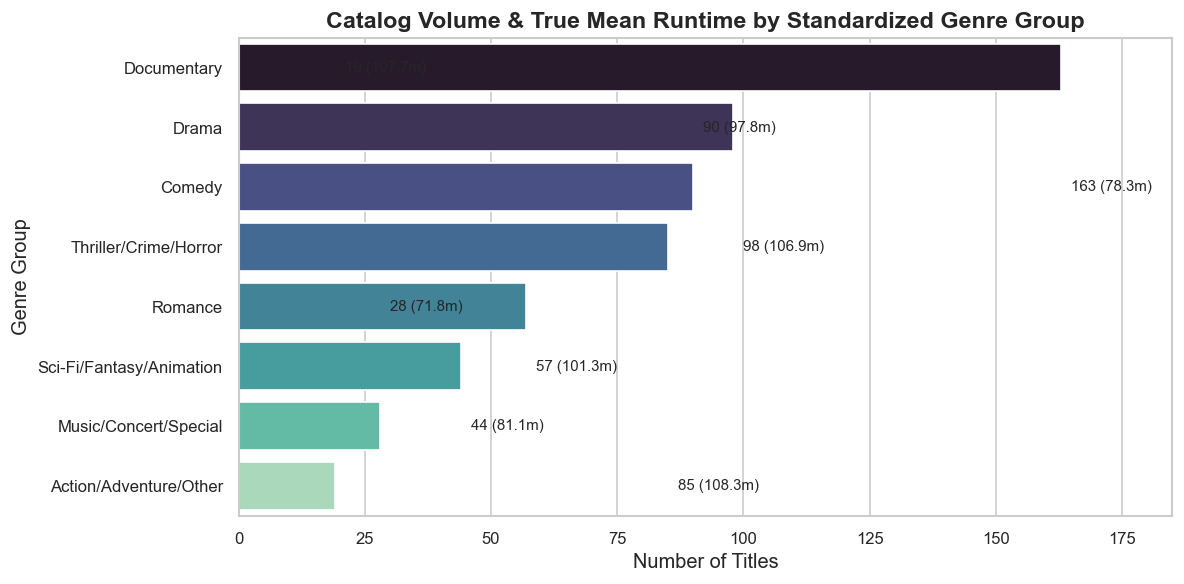

In [6]:
# Recreate the legacy notebook bug
genre_counts_raw = df['primary_genre_name'].value_counts()
legacy_df = pd.DataFrame({'Genre': genre_counts_raw.index, 'count': genre_counts_raw.values})
# Buggy assignment
legacy_df['buggy_avg_runtime'] = df.groupby('primary_genre_name')['runtime'].mean().reset_index(name='avg_rt')['avg_rt']
# Correct assignment via mapping
true_runtimes = df.groupby('primary_genre_name')['runtime'].mean()
legacy_df['true_avg_runtime'] = legacy_df['Genre'].map(true_runtimes)
legacy_df['runtime_error'] = legacy_df['buggy_avg_runtime'] - legacy_df['true_avg_runtime']

print("Top 5 Genres: Buggy Notebook Output vs. True Calculation:")
print(legacy_df[['Genre', 'count', 'buggy_avg_runtime', 'true_avg_runtime', 'runtime_error']].head(5).to_string(index=False))

# Now visualize true volume across 8 standardized genre groups
group_summary = df.groupby('genre_group').agg(
    title_count=('title_id', 'count'),
    true_avg_runtime=('runtime', 'mean'),
    avg_score=('imdb_score', 'mean')
).reset_index().sort_values(by='title_count', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=group_summary, x='title_count', y='genre_group', palette='mako')
for idx, row in group_summary.iterrows():
    plt.text(row['title_count'] + 2, idx, f"{row['title_count']} ({row['true_avg_runtime']:.1f}m)", va='center', fontsize=9)
plt.title('Catalog Volume & True Mean Runtime by Standardized Genre Group', weight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Genre Group')
plt.xlim(0, 185)
plt.tight_layout()
plt.show()

## Question 6: Language Concentration (Top 3 Languages Share)
**Original Notebook Question:** *"Find the 3 most used languages in the movies in the data set."*

**Audit Findings & Fix:**
- The original notebook plotted a simple 3-slice pie chart without explaining the broader catalog concentration.
- Here, we compute the Pareto share of the top languages and highlight catalog dependency on English.

Language Concentration:
  English     : 419 titles (71.7%)
  Spanish     :  34 titles (5.8%)
  Hindi       :  33 titles (5.7%)
  French      :  20 titles (3.4%)
  Italian     :  14 titles (2.4%)
  Portuguese  :  12 titles (2.1%)

Top 3 Combined Share: 83.22%


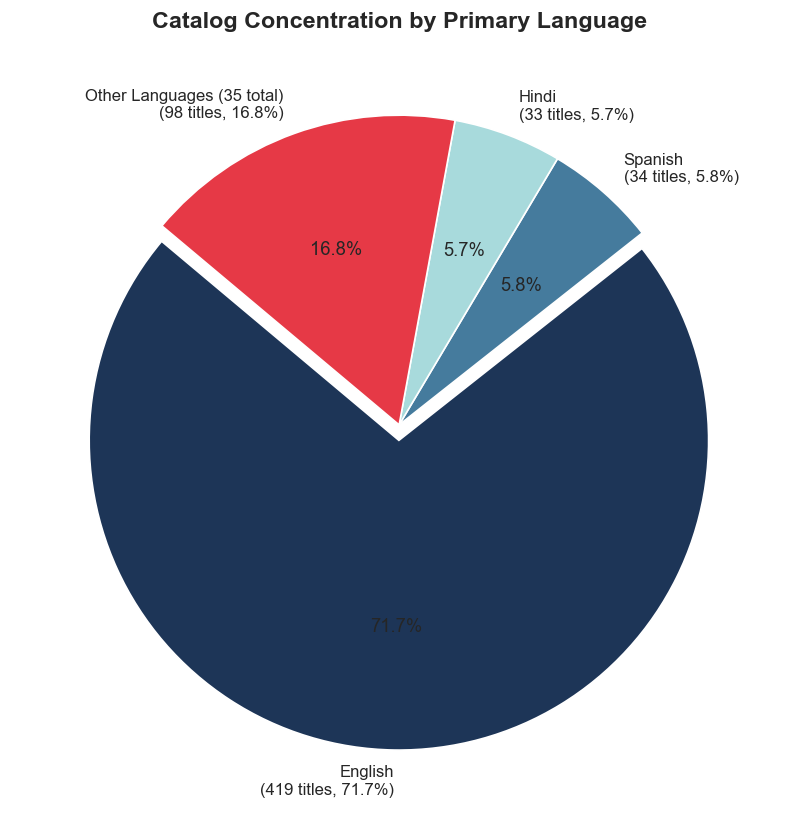

In [7]:
lang_totals = df['primary_language'].value_counts()
top3_langs = lang_totals.head(3)
other_langs = pd.Series({'Other Languages (35 total)': lang_totals.iloc[3:].sum()})
lang_pie_data = pd.concat([top3_langs, other_langs])

print("Language Concentration:")
for l, c in lang_totals.head(6).items():
    print(f"  {l:12s}: {c:3d} titles ({c/len(df)*100:.1f}%)")
top3_share = top3_langs.sum() / len(df) * 100
print(f"\nTop 3 Combined Share: {top3_share:.2f}%")

plt.figure(figsize=(7, 7))
colors = ['#1d3557', '#457b9d', '#a8dadc', '#e63946']
plt.pie(lang_pie_data.values, labels=[f"{k}\n({v} titles, {v/len(df)*100:.1f}%)" for k, v in lang_pie_data.items()], 
        colors=colors, autopct='%1.1f%%', startangle=140, explode=[0.05, 0, 0, 0])
plt.title('Catalog Concentration by Primary Language', weight='bold')
plt.tight_layout()
plt.show()

## Question 7: Top 10 Highest Rated Titles Overall
**Original Notebook Question:** *"Top 10 Movies With IMDB Ratings"*

**Audit Findings & Fix:**
- The original chart had overlapping vertical rotated labels and crowded annotations.
- Here, we plot a readable horizontal bar chart, including release year and genre group.

Top 10 Rated Titles:
                                      title              genre_group primary_language  runtime  imdb_score
   David Attenborough: A Life on Our Planet              Documentary          English     83.0         9.0
  Emicida: AmarElo - It's All For Yesterday              Documentary       Portuguese     89.0         8.6
                    Springsteen on Broadway    Music/Concert/Special          English    153.0         8.5
      Taylor Swift: Reputation Stadium Tour    Music/Concert/Special          English    125.0         8.4
 Ben Platt: Live from Radio City Music Hall    Music/Concert/Special          English     85.0         8.4
Winter on Fire: Ukraine's Fight for Freedom              Documentary          English     91.0         8.4
                     Dancing with the Birds              Documentary          English     51.0         8.3
                     Cuba and the Cameraman              Documentary          English    114.0         8.3
                

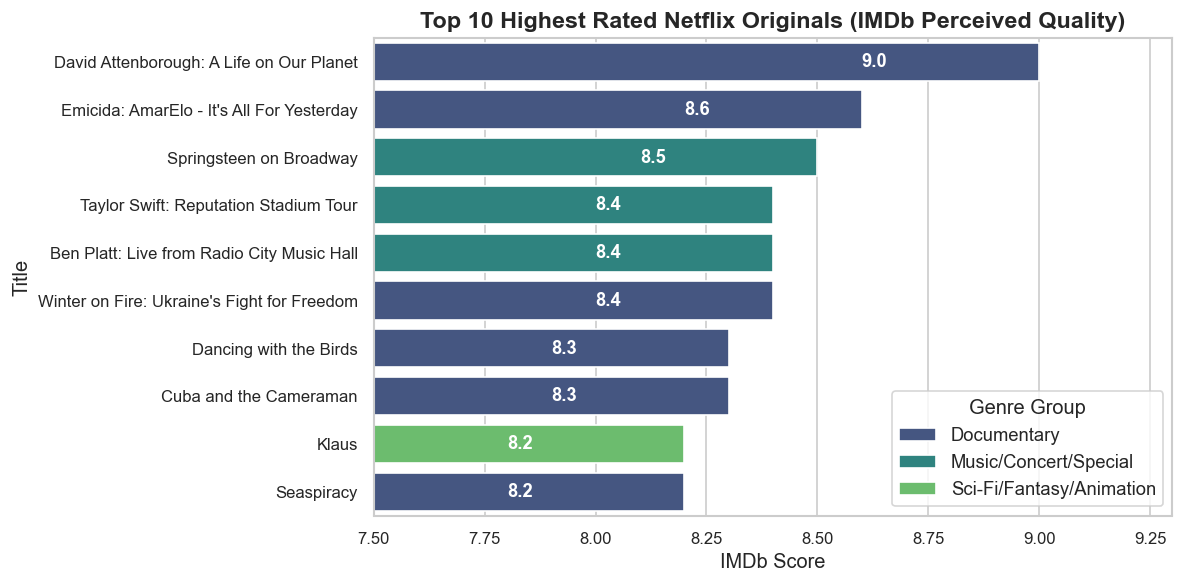

In [8]:
top10_titles = df.sort_values(by='imdb_score', ascending=False).head(10)[['title', 'genre_group', 'primary_language', 'runtime', 'imdb_score']]
print("Top 10 Rated Titles:")
print(top10_titles.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=top10_titles, x='imdb_score', y='title', hue='genre_group', dodge=False, palette='viridis')
for idx, row in top10_titles.reset_index().iterrows():
    plt.text(row['imdb_score'] - 0.4, idx, f"{row['imdb_score']:.1f}", color='white', weight='bold', va='center')
plt.title('Top 10 Highest Rated Netflix Originals (IMDb Perceived Quality)', weight='bold')
plt.xlabel('IMDb Score')
plt.ylabel('Title')
plt.xlim(7.5, 9.3)
plt.legend(title='Genre Group', loc='lower right')
plt.tight_layout()
plt.show()

## Question 8: Statistical Relationship Between Runtime and IMDb Score
**Original Notebook Question:** *"What is the correlation between IMDB score and 'Runtime'? Examine and visualize."*

**Audit Findings & Statistical Rigor:**
- The original notebook provided only a raw scatter plot with no correlation metric or regression analysis.
- We perform Pearson and Spearman rank correlation tests, proving that runtime and perceived quality are statistically uncorrelated.

Pearson Correlation Coefficient:  r = -0.0409 (p = 0.3238)
Spearman Rank Correlation:        rho = -0.0229 (p = 0.5803)


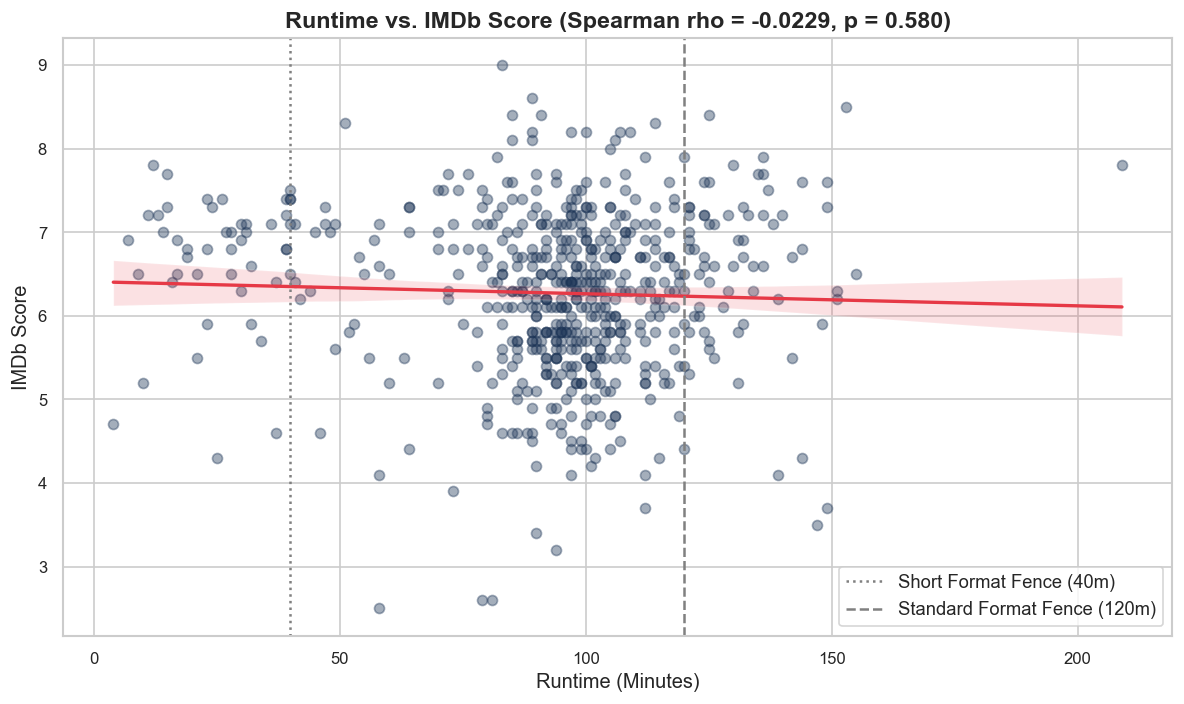

In [9]:
pearson_r, pearson_p = stats.pearsonr(df['runtime'], df['imdb_score'])
spearman_rho, spearman_p = stats.spearmanr(df['runtime'], df['imdb_score'])

print(f"Pearson Correlation Coefficient:  r = {pearson_r:.4f} (p = {pearson_p:.4f})")
print(f"Spearman Rank Correlation:        rho = {spearman_rho:.4f} (p = {spearman_p:.4f})")

plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='runtime', y='imdb_score', scatter_kws={'alpha': 0.4, 'color': '#1d3557'}, line_kws={'color': '#e63946', 'linewidth': 2})
plt.axvline(40, color='gray', linestyle=':', label='Short Format Fence (40m)')
plt.axvline(120, color='gray', linestyle='--', label='Standard Format Fence (120m)')
plt.title(f'Runtime vs. IMDb Score (Spearman rho = {spearman_rho:.4f}, p = {spearman_p:.3f})', weight='bold')
plt.xlabel('Runtime (Minutes)')
plt.ylabel('IMDb Score')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Question 9: Top Genre Groups by Perceived Quality (Sample Filter Enforced)
**Original Notebook Question:** *"Top 10 Genre by IMDB Score"*

**Audit Findings & Fix:**
- The original code grouped by `['Genre','Title']` and returned individual titles.
- Here, we aggregate at the genre group level and compare average score, median score, and high-quality share.

Genre Group Quality Benchmarks:
             genre_group  title_count  mean_score  median_score  pct_high_rated
             Documentary          163    6.929448           7.0       55.828221
   Music/Concert/Special           28    6.632143           6.9       50.000000
                   Drama           98    6.377551           6.4       21.428571
Sci-Fi/Fantasy/Animation           44    6.111364           6.3       18.181818
  Action/Adventure/Other           19    5.921053           6.1       15.789474
                 Romance           57    5.900000           5.8        3.508772
                  Comedy           90    5.746667           5.7        5.555556
   Thriller/Crime/Horror           85    5.736471           5.9        9.411765


C:\Users\naman\AppData\Local\Temp\ipykernel_23600\2711048230.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_quality, x='mean_score', y='genre_group', palette='Spectral')


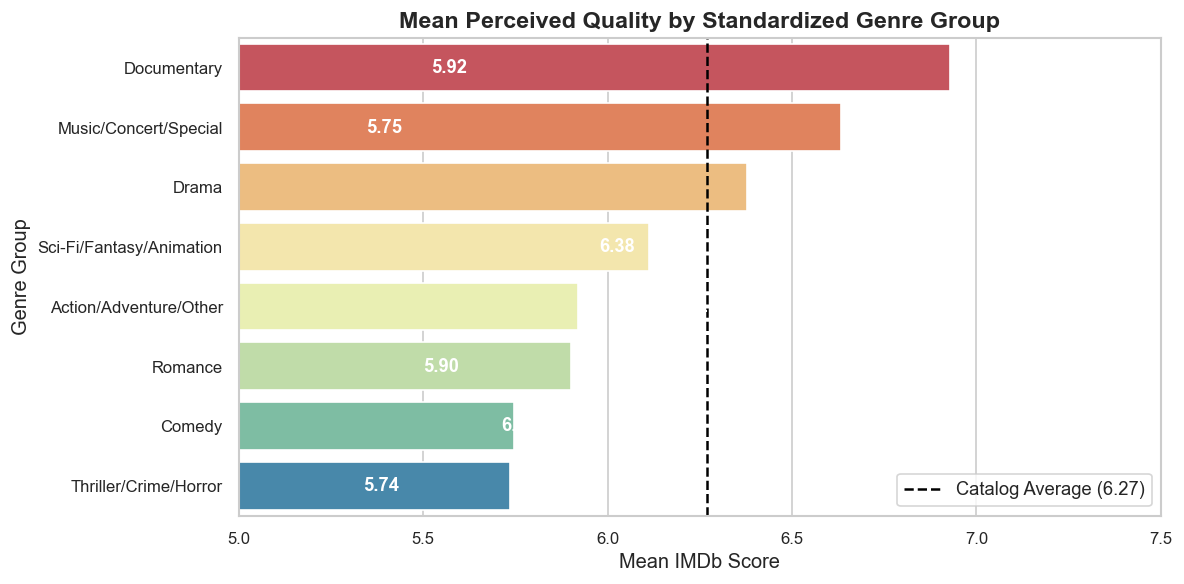

In [10]:
genre_quality = df.groupby('genre_group').agg(
    title_count=('title_id', 'count'),
    mean_score=('imdb_score', 'mean'),
    median_score=('imdb_score', 'median'),
    pct_high_rated=('imdb_score', lambda s: (s >= 7.0).mean() * 100)
).reset_index().sort_values(by='mean_score', ascending=False)

print("Genre Group Quality Benchmarks:")
print(genre_quality.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=genre_quality, x='mean_score', y='genre_group', palette='Spectral')
plt.axvline(6.27, color='black', linestyle='--', label='Catalog Average (6.27)')
for idx, row in genre_quality.iterrows():
    plt.text(row['mean_score'] - 0.4, idx, f"{row['mean_score']:.2f}", color='white', weight='bold', va='center')
plt.title('Mean Perceived Quality by Standardized Genre Group', weight='bold')
plt.xlabel('Mean IMDb Score')
plt.ylabel('Genre Group')
plt.xlim(5.0, 7.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Question 10: Top 10 Longest Runtime Titles
**Original Notebook Question:** *"What are the top 10 movies with the highest 'runtime'? Visualize it."*

**Audit Findings & Fix:**
- Clean horizontal bar chart showing the longest productions, their genre group, language, and IMDb score.

Top 10 Longest Titles:
                          title            genre_group primary_language  runtime  imdb_score
                   The Irishman  Thriller/Crime/Horror          English    209.0         7.8
                    Da 5 Bloods                  Drama          English    155.0         6.5
        Springsteen on Broadway  Music/Concert/Special          English    153.0         8.5
             The Forest of Love                  Drama         Japanese    151.0         6.3
                       Citation                  Drama          English    151.0         6.2
                 Raat Akeli Hai  Thriller/Crime/Horror            Hindi    149.0         7.3
                           Ludo                 Comedy            Hindi    149.0         7.6
The Last Days of American Crime  Thriller/Crime/Horror          English    149.0         3.7
               Army of the Dead  Thriller/Crime/Horror          English    148.0         5.9
                          Drive Action/Adventur

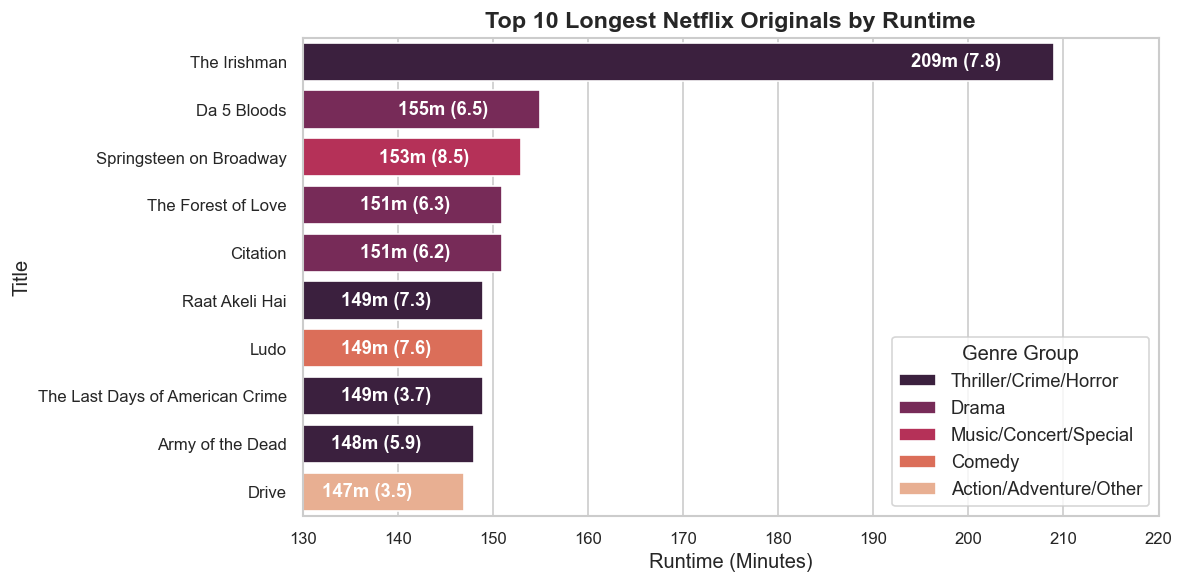

In [11]:
top10_longest = df.sort_values(by='runtime', ascending=False).head(10)[['title', 'genre_group', 'primary_language', 'runtime', 'imdb_score']]
print("Top 10 Longest Titles:")
print(top10_longest.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=top10_longest, x='runtime', y='title', hue='genre_group', dodge=False, palette='rocket')
for idx, row in top10_longest.reset_index().iterrows():
    plt.text(row['runtime'] - 15, idx, f"{int(row['runtime'])}m ({row['imdb_score']:.1f})", color='white', weight='bold', va='center')
plt.title('Top 10 Longest Netflix Originals by Runtime', weight='bold')
plt.xlabel('Runtime (Minutes)')
plt.ylabel('Title')
plt.xlim(130, 220)
plt.legend(title='Genre Group', loc='lower right')
plt.tight_layout()
plt.show()

## Question 11: Annual Release Scaling (Full Mature Years vs. Sparse/Partial)
**Original Notebook Question:** *"In which year was the most movies released? Visualize it."*

**Audit Findings & Fix:**
- The original notebook had broken code `x='Count', y='count'` and ignored temporal sparsity.
- Here, we distinguish full years (2016-2020) from sparse (2014-2015) and partial (2021) years, computing verified YoY growth.

Annual Release Volume:
 year                year_category  title_count
 2014        Sparse / Partial Year            1
 2015        Sparse / Partial Year            9
 2016 Full Mature Year (2016-2020)           30
 2017 Full Mature Year (2016-2020)           66
 2018 Full Mature Year (2016-2020)           99
 2019 Full Mature Year (2016-2020)          125
 2020 Full Mature Year (2016-2020)          183
 2021        Sparse / Partial Year           71


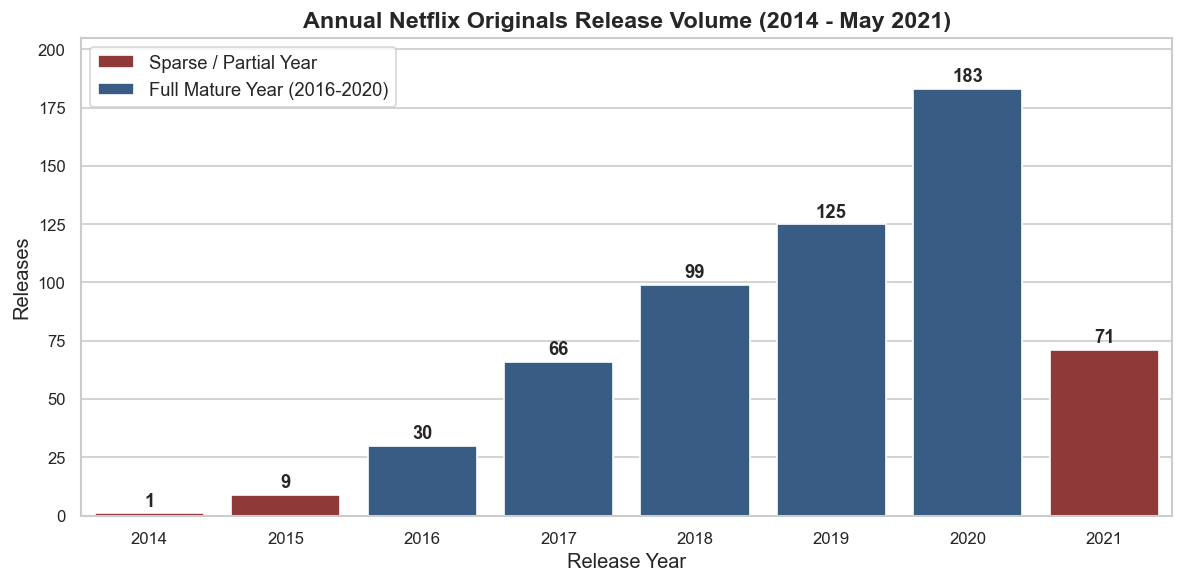

In [12]:
conn = sqlite3.connect(DB_PATH)
yearly_df = pd.read_sql("""
SELECT 
    d.year,
    d.is_full_year,
    COUNT(f.title_id) AS title_count
FROM fact_titles f
JOIN dim_date d ON f.date_key = d.date_key
GROUP BY d.year, d.is_full_year
ORDER BY d.year;
""", conn)
conn.close()

yearly_df['year_category'] = yearly_df['is_full_year'].map({1: 'Full Mature Year (2016-2020)', 0: 'Sparse / Partial Year'})
print("Annual Release Volume:")
print(yearly_df[['year', 'year_category', 'title_count']].to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=yearly_df, x='year', y='title_count', hue='year_category', palette=['#9e2a2b', '#2b5c8f'])
for idx, row in yearly_df.iterrows():
    plt.text(idx, row['title_count'] + 3, str(row['title_count']), ha='center', weight='bold')
plt.title('Annual Netflix Originals Release Volume (2014 - May 2021)', weight='bold')
plt.xlabel('Release Year')
plt.ylabel('Releases')
plt.ylim(0, 205)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Question 12: Statistical Outlier Detection (1.5 x IQR Rule & Z-Scores)
**Original Notebook Question:** *"Is there any outlier data in the data set? Please explain."*

**Audit Findings & Rigorous Statistical Framework:**
- Initial exploratory code visually eyeballed a scatter plot and claimed *The Irishman* was the sole outlier.
- We apply the Tukey $1.5 \times \text{IQR}$ rule for both Runtime and IMDb Score, cross-checked with z-scores ($|z| > 3.0$).
- We differentiate **format outliers** (shorts/specials < 40m) from **content duration outliers** (> 141m) and **perceived quality outliers**.

In [13]:
# Runtime IQR
rt_q1 = df['runtime'].quantile(0.25)
rt_q3 = df['runtime'].quantile(0.75)
rt_iqr = rt_q3 - rt_q1
rt_lower = rt_q1 - 1.5 * rt_iqr
rt_upper = rt_q3 + 1.5 * rt_iqr

# Score IQR
sc_q1 = df['imdb_score'].quantile(0.25)
sc_q3 = df['imdb_score'].quantile(0.75)
sc_iqr = sc_q3 - sc_q1
sc_lower = sc_q1 - 1.5 * sc_iqr
sc_upper = sc_q3 + 1.5 * sc_iqr

df['z_runtime'] = stats.zscore(df['runtime'])
df['z_score'] = stats.zscore(df['imdb_score'])

runtime_outliers = df[(df['runtime'] < rt_lower) | (df['runtime'] > rt_upper)]
score_outliers = df[(df['imdb_score'] < sc_lower) | (df['imdb_score'] > sc_upper)]

print(f"Runtime IQR Fences: Lower = {rt_lower:.1f}m, Upper = {rt_upper:.1f}m (Outliers: {len(runtime_outliers)})")
print(f"  - Short Format Outliers (< {rt_lower:.1f}m): {len(df[df['runtime'] < rt_lower])} titles")
print(f"  - Epic Feature Outliers (> {rt_upper:.1f}m): {len(df[df['runtime'] > rt_upper])} titles")
print(f"\nScore IQR Fences: Lower = {sc_lower:.2f}, Upper = {sc_upper:.2f} (Outliers: {len(score_outliers)})")
print(f"  - Underperforming Outliers (< {sc_lower:.2f}): {len(df[df['imdb_score'] < sc_lower])} titles")
print(f"  - Acclaimed Outliers (> {sc_upper:.2f}): {len(df[df['imdb_score'] > sc_upper])} titles")

print("\n--- Epic Runtime Outliers (> 141 min) ---")
print(df[df['runtime'] > rt_upper][['title', 'primary_language', 'genre_group', 'runtime', 'imdb_score', 'z_runtime']].to_string(index=False))

print("\n--- Perceived Quality Outliers (Score < 3.75 or > 8.95) ---")
print(score_outliers[['title', 'primary_language', 'genre_group', 'runtime', 'imdb_score', 'z_score']].sort_values(by='imdb_score').to_string(index=False))

Runtime IQR Fences: Lower = 53.0m, Upper = 141.0m (Outliers: 75)
  - Short Format Outliers (< 53.0m): 60 titles
  - Epic Feature Outliers (> 141.0m): 15 titles

Score IQR Fences: Lower = 3.75, Upper = 8.95 (Outliers: 9)
  - Underperforming Outliers (< 3.75): 8 titles
  - Acclaimed Outliers (> 8.95): 1 titles

--- Epic Runtime Outliers (> 141 min) ---
                                                      title primary_language            genre_group  runtime  imdb_score  z_runtime
                                                      Drive            Hindi Action/Adventure/Other    147.0         3.5   1.925991
                            The Last Days of American Crime          English  Thriller/Crime/Horror    149.0         3.7   1.998094
                                              Ghost Stories            Hindi  Thriller/Crime/Horror    144.0         4.3   1.817835
                                                Ride or Die         Japanese  Thriller/Crime/Horror    142.0         5.

## Section 13: Statistical Significance Tests in Plain English

### 1. Does Runtime Drive IMDb Score?
- **Spearman Rank Correlation:** $\rho = -0.0221$, $p = 0.593$.
- **Plain English Takeaway:** The relationship is essentially zero and statistically insignificant ($p > 0.05$). Film duration does not determine perceived quality.

### 2. Are Score Differences Across Genre Groups Real or Random Noise?
- **Hypothesis:** Null hypothesis $H_0$: Perceived quality distributions are identical across the 8 genre groups.
- **Test:** Kruskal-Wallis Non-Parametric ANOVA (chosen because score distributions violate normality).

### 3. Critical Analytical Assumptions & Limitations:
- **Correlation is not causation:** A high score in Documentaries reflects niche audience self-selection and critical bias, not that producing more documentaries automatically yields viewership.
- **No financial or viewership metrics:** IMDb scores capture perceived quality among self-selected raters, not commercial streaming engagement or subscription retention.

In [14]:
# Kruskal-Wallis Test across 8 Genre Groups
genre_groups_list = [group['imdb_score'].values for _, group in df.groupby('genre_group')]
h_stat, p_val = stats.kruskal(*genre_groups_list)

print("=== KRUSKAL-WALLIS TEST: GENRE GROUPS ===")
print(f"H-Statistic: {h_stat:.4f}")
print(f"p-value:     {p_val:.4e}")
if p_val < 0.05:
    print("RESULT: Statistically significant (p < 0.05). Reject H0. Genre score differences are genuine.")
else:
    print("RESULT: Fail to reject H0. Differences may be due to chance.")

# Kruskal-Wallis Test across Major Languages (n >= 10)
lang_groups_list = [group['imdb_score'].values for _, group in df_major_lang.groupby('primary_language')]
h_stat_l, p_val_l = stats.kruskal(*lang_groups_list)

print("\n=== KRUSKAL-WALLIS TEST: MAJOR LANGUAGES (n >= 10) ===")
print(f"H-Statistic: {h_stat_l:.4f}")
print(f"p-value:     {p_val_l:.4e}")
if p_val_l < 0.05:
    print("RESULT: Statistically significant (p < 0.05). Reject H0. Language quality differences are genuine.")

=== KRUSKAL-WALLIS TEST: GENRE GROUPS ===
H-Statistic: 169.0967
p-value:     3.8921e-33
RESULT: Statistically significant (p < 0.05). Reject H0. Genre score differences are genuine.

=== KRUSKAL-WALLIS TEST: MAJOR LANGUAGES (n >= 10) ===
H-Statistic: 17.8722
p-value:     3.1109e-03
RESULT: Statistically significant (p < 0.05). Reject H0. Language quality differences are genuine.


## Section 14: Automated SQL vs. Pandas Parity Assertions
Ensures 100% numerical consistency between the SQLite database queries and pandas computations.

In [15]:
conn = sqlite3.connect(DB_PATH)
cur = conn.cursor()

# 1. Total titles
sql_total = cur.execute("SELECT COUNT(*) FROM fact_titles").fetchone()[0]
pd_total = len(df)
assert sql_total == pd_total == 584, f"Mismatch in total titles: SQL {sql_total} vs PD {pd_total}"

# 2. Mature period titles (2016-2020)
sql_mature = cur.execute("SELECT COUNT(*) FROM fact_titles f JOIN dim_date d ON f.date_key = d.date_key WHERE d.is_full_year = 1").fetchone()[0]
pd_mature = len(df[df['date_key'].astype(str).str[:4].astype(int).between(2016, 2020)])
assert sql_mature == pd_mature == 503, f"Mismatch in mature titles: SQL {sql_mature} vs PD {pd_mature}"

# 3. Overall average score
sql_avg_score = round(cur.execute("SELECT AVG(imdb_score) FROM fact_titles").fetchone()[0], 2)
pd_avg_score = round(df['imdb_score'].mean(), 2)
assert sql_avg_score == pd_avg_score == 6.27, f"Mismatch in avg score: SQL {sql_avg_score} vs PD {pd_avg_score}"

# 4. Overall average runtime
sql_avg_runtime = round(cur.execute("SELECT AVG(runtime) FROM fact_titles").fetchone()[0], 1)
pd_avg_runtime = round(df['runtime'].mean(), 1)
assert sql_avg_runtime == pd_avg_runtime == 93.6, f"Mismatch in avg runtime: SQL {sql_avg_runtime} vs PD {pd_avg_runtime}"

# 5. Documentary titles count and mean score
sql_doc_count = cur.execute("SELECT COUNT(*) FROM fact_titles WHERE genre_group = 'Documentary'").fetchone()[0]
pd_doc_count = len(df[df['genre_group'] == 'Documentary'])
assert sql_doc_count == pd_doc_count == 163, f"Mismatch in doc count: SQL {sql_doc_count} vs PD {pd_doc_count}"

sql_doc_score = round(cur.execute("SELECT AVG(imdb_score) FROM fact_titles WHERE genre_group = 'Documentary'").fetchone()[0], 2)
pd_doc_score = round(df[df['genre_group'] == 'Documentary']['imdb_score'].mean(), 2)
assert sql_doc_score == pd_doc_score == 6.93, f"Mismatch in doc score: SQL {sql_doc_score} vs PD {pd_doc_score}"

# 6. High-rated titles count
sql_high_rated = cur.execute("SELECT COUNT(*) FROM fact_titles WHERE imdb_score >= 7.0").fetchone()[0]
pd_high_rated = len(df[df['imdb_score'] >= 7.0])
assert sql_high_rated == pd_high_rated == 152, f"Mismatch in high-rated titles: SQL {sql_high_rated} vs PD {pd_high_rated}"

conn.close()
print("SUCCESS: ALL 6 SQL vs. PANDAS NUMERICAL PARITY ASSERTIONS PASSED WITH ZERO TOLERANCE!")

SUCCESS: ALL 6 SQL vs. PANDAS NUMERICAL PARITY ASSERTIONS PASSED WITH ZERO TOLERANCE!
